"""
rc_scopus_fig1.py
=================
Loads Scopus RC exports (2000-2015 and 2016-2025), normalises them to the
same schema used by rc_plot_scopus.ipynb, classifies each paper into a
subfield, deduplicates, writes rc_papers_merged_scopus.csv, then produces
the same Fig 1 family as the OpenAlex version:
 
  rc_scopus_landscape.png
  rc_scopus_landscape_normalized.png
  rc_scopus_landscape_early_window.png
  rc_scopus_landscape_early_window_normalized.png
  rc_scopus_Fig1.png                  ← composite grid (main output)
 
Usage
-----
    python rc_scopus_fig1.py
 
Adjust the two FILE PATH constants at the top of the CONFIG block if your
CSV files live somewhere else.
"""

In [21]:
import csv
import re
import sys
from collections import defaultdict
from pathlib import Path
 
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec

1. Config

In [22]:
# Import constants and helper functions from scopus_data_analyze
import scopus_data_analyze as scopus

SUBFIELD_COLORS = scopus.SUBFIELD_COLORS
SUBFIELD_ORDER = scopus.SUBFIELD_ORDER
SUBFIELD_RULES = scopus.SUBFIELD_RULES
RC_CORE_TERMS = scopus.RC_CORE_TERMS
RC_EXCLUDE_TERMS = scopus.RC_EXCLUDE_TERMS

# Helper functions
load_landmarks = scopus.load_landmarks
build_matrix = scopus.build_matrix
build_matrix_early_window = scopus.build_matrix_early_window
load_csv = scopus.load_csv

In [23]:
YEARS           = (2000, 2025)
EARLY_WINDOW_END = 2005

# ══════════════════════════════════════════════════════════════════════
# FILE PATHS & CONFIG
# ══════════════════════════════════════════════════════════════════════
SCOPUS_CSV_2000_2015 = "cocitation_diagrams_files/scopus_export_2000_2015.csv"
SCOPUS_CSV_2016_2025 = "cocitation_diagrams_files/scopus_export_2016_2025.csv"
OUTPUT_MERGED   = "rc_papers_merged_scopus.csv"
OUTPUT_ABS      = "rc_scopus_landscape.png"
OUTPUT_NORM     = "rc_scopus_landscape_normalized.png"
OUTPUT_ABS_EARLY = "rc_landscape_early_window.png"
OUTPUT_NORM_EARLY = "rc_landscape_early_window_normalized.png"
OUTPUT_FIG1     = "rc_scopus_Fig1.png"
LANDMARK_CSV    = "rc_landmark_papers.csv"

OUTPUT_FIELDS = ["title", "year", "citations", "doi", "subfield", "landmark_subfield", "landmark", "landmark_authors", "cites_per_year"]
DEFAULT_SUBFIELD = "Other / Interdisciplinary"

# ══════════════════════════════════════════════════════════════════════
# SHARED STYLE HELPERS
# ══════════════════════════════════════════════════════════════════════

def _style(ax):
    ax.tick_params(colors="black", labelsize=12)
    ax.set_xticks(range(YEARS[0], YEARS[1] + 1, 2))
    for spine in ax.spines.values():
        spine.set_edgecolor("#666")
    ax.yaxis.grid(False)
    ax.set_axisbelow(True)


def _style_early_window(ax, years):
    ax.tick_params(colors="black", labelsize=18)
    ticks  = [EARLY_WINDOW_END] + [y for y in range(EARLY_WINDOW_END + 2, YEARS[1] + 1, 2)]
    labels = [f"{YEARS[0]}-{EARLY_WINDOW_END}"] + [str(y) for y in ticks[1:]]
    ax.set_xticks(ticks)
    ax.set_xticklabels(labels)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.yaxis.grid(False)
    ax.set_axisbelow(True)


def _legend(ax, order, matrix, totals, normalised):
    thresh  = 0.03 if normalised else (totals[-1] * 0.03 if totals[-1] else 0)
    handles = [
        mpatches.Patch(color=SUBFIELD_COLORS.get(sf, "#aaa"), label=sf, alpha=0.88)
        for i, sf in enumerate(order)
        if matrix[i].sum() > 0 and matrix[i, -1] <= thresh
    ]
    handles.append(
        plt.Line2D([0], [0], marker="*", color="black", markersize=12,
                   lw=0, markeredgecolor="#FFD700", markeredgewidth=0.8,
                   label="Landmark (in band)"),
    )
    ax.legend(handles=handles, loc="upper left", fontsize=11,
              framealpha=0.85, facecolor="white", edgecolor="#999",
              ncol=1, labelcolor="black", borderpad=0.8)


def draw_band_labels(ax, order, matrix, totals, years, normalised):
    col_total = np.where(totals > 0, totals, 1.0)
    cum = np.zeros(matrix.shape[1])
    for i, sf in enumerate(order):
        heights = matrix[i] / col_total if normalised else matrix[i]
        mid_y   = cum[-1] + heights[-1] / 2.0
        thresh  = 0.03 if normalised else totals[-1] * 0.03
        if matrix[i].sum() > 0 and heights[-1] > thresh:
            ax.text(years[-1] + 0.3, mid_y, sf,
                    fontsize=24, color="black", va="center", alpha=0.9)
        cum += heights


def draw_band_labels_early(ax, order, matrix, totals, years, normalised):
    col_total = np.where(totals > 0, totals, 1.0)
    cum = np.zeros(matrix.shape[1])
    candidates = []
    for i, sf in enumerate(order):
        heights = matrix[i] / col_total if normalised else matrix[i]
        mid_y   = cum[-1] + heights[-1] / 2.0
        show = (matrix[i].sum() > 0 and heights[-1] > 0.005) if normalised \
               else (matrix[i].sum() > 0 and heights[-1] > max(1.0, totals[-1] * 0.005))
        if show:
            candidates.append((mid_y, sf))
        cum += heights

    if not candidates:
        return

    candidates.sort(key=lambda x: x[0])
    y_min, y_max = ax.get_ylim()
    gap = 0.03 if normalised else max(18.0, (y_max - y_min) * 0.02)
    adjusted = []
    for y, sf in candidates:
        y_new = y if not adjusted else max(y, adjusted[-1][0] + gap)
        adjusted.append((y_new, sf))
    overflow = adjusted[-1][0] - (y_max - gap)
    if overflow > 0:
        adjusted = [(max(y_min + gap, y - overflow), sf) for y, sf in adjusted]
    for y, sf in adjusted:
        ax.text(years[-1] + 0.25, y, sf,
                fontsize=24, color=SUBFIELD_COLORS.get(sf, "black"),
                va="center", ha="left", alpha=0.95)


# ══════════════════════════════════════════════════════════════════════
# LANDMARK PLACEMENT
# ══════════════════════════════════════════════════════════════════════

def place_landmarks(ax, landmarks, order, matrix, years, totals, normalised):
    col_total = np.where(totals > 0, totals, 1.0)
    groups    = defaultdict(list)
    for p in landmarks:
        try:
            yr = int(p.get("year"))
        except (TypeError, ValueError):
            continue
        if not (YEARS[0] <= yr <= YEARS[1]):
            continue
        sf = (p.get("landmark_subfield") or p.get("subfield") or DEFAULT_SUBFIELD)
        groups[(sf, yr)].append(p)

    ann_yr_count         = defaultdict(int)
    used_ann_y_by_year   = defaultdict(list)

    for (sf, yr), group in sorted(groups.items(), key=lambda kv: kv[0][1]):
        idx = yr - years[0]
        if idx < 0 or idx >= matrix.shape[1]:
            continue
        bottom = band_b = band_t = 0.0
        for i, s in enumerate(order):
            h = matrix[i, idx] / col_total[idx] if normalised else matrix[i, idx]
            if s == sf:
                band_b = bottom; band_t = bottom + h; break
            bottom += h
        if band_b is None or (band_t - band_b) < 1e-6:
            continue

        n_in_grp  = len(group)
        sf_color  = SUBFIELD_COLORS.get(sf, "#FFD700")
        stack_top = (totals[idx] / col_total[idx]) if normalised else totals[idx]

        for k, p in enumerate(sorted(group, key=lambda x: -(float(x.get("cites_per_year") or 0)))):
            frac  = (k + 0.5) / n_in_grp
            ystar = band_b + frac * (band_t - band_b)
            ax.plot(yr, ystar, marker="*", color="black", markersize=16, zorder=12,
                    markeredgecolor=sf_color, markeredgewidth=0.8)

            ann_n   = ann_yr_count[yr]; ann_yr_count[yr] += 1
            if normalised:
                ann_y   = min(0.98, ystar + 0.05 + ann_n * 0.03)
                x_shift = 0.15 + ann_n * 0.4
            else:
                ann_y   = stack_top + stack_top * 0.06 + ann_n * stack_top * 0.08
                x_shift = 0.15 + ann_n * 0.5

            title_s = (p.get("title") or "")[:36]
            reason  = (p.get("landmark") or "").strip()[:40]
            ax.annotate(f"{title_s}\n{reason}",
                        xy=(yr, ystar), xytext=(yr + x_shift, ann_y),
                        fontsize=14, color=sf_color, alpha=0.95, zorder=13,
                        va="bottom", ha="left",
                        arrowprops=dict(arrowstyle="-", color=sf_color, alpha=0.45,
                                        lw=0.55, connectionstyle="arc3,rad=0.1"),
                        bbox=dict(boxstyle="round,pad=0.22", fc="white",
                                  ec=sf_color, alpha=0.85, lw=0.6))


def format_landmark_label(p):
    authors_raw = (p.get("landmark_authors") or "").strip() or "Unknown et al."
    first       = authors_raw.split("/")[0].strip()
    surname     = first.split()[0].replace(".", "") if first else "Unknown"
    author_part = f"{surname} et al."
    title       = (p.get("title") or "Untitled").strip().replace('"', '')
    words       = title.split()
    keyword     = " ".join(words[:4]).lower() + ("..." if len(words) > 4 else "")
    return f"{author_part} '{keyword}'"


def place_landmarks_early_window(ax, landmarks, order, matrix, years, totals,
                                  normalised, early_end=EARLY_WINDOW_END):
    col_total    = np.where(totals > 0, totals, 1.0)
    year_to_idx  = {y: i for i, y in enumerate(years)}
    groups       = defaultdict(list)
    for p in landmarks:
        try:
            yr = int(p.get("year"))
        except (TypeError, ValueError):
            continue
        if yr > YEARS[1]:
            continue
        yrb = early_end if yr <= early_end else yr
        if yrb not in year_to_idx:
            continue
        sf = (p.get("landmark_subfield") or p.get("subfield") or DEFAULT_SUBFIELD)
        groups[(sf, yrb)].append(p)

    ann_yr_count       = defaultdict(int)
    used_ann_y_by_year = defaultdict(list)

    for (sf, yr), group in sorted(groups.items(), key=lambda kv: kv[0][1]):
        idx    = year_to_idx[yr]
        bottom = band_b = band_t = 0.0
        for i, s in enumerate(order):
            h = matrix[i, idx] / col_total[idx] if normalised else matrix[i, idx]
            if s == sf:
                band_b = bottom; band_t = bottom + h; break
            bottom += h
        if band_b is None or (band_t - band_b) < 1e-6:
            continue

        n_in_grp = len(group)
        sf_color = SUBFIELD_COLORS.get(sf, "#FFD700")

        for k, p in enumerate(sorted(group, key=lambda x: -(float(x.get("cites_per_year") or 0)))):
            frac  = (k + 0.5) / n_in_grp
            ystar = band_b + frac * (band_t - band_b)
            ax.plot(yr, ystar, marker="*", color="black", markersize=18, zorder=12,
                    markeredgecolor=sf_color, markeredgewidth=0.8)

            ann_n      = ann_yr_count[yr]; ann_yr_count[yr] += 1
            stack_top  = totals[idx]
            crowded_sf = {"Signal Processing & Comms", "Mathematics & Theory",
                          "Neuroscience & Comp. Neuro"}
            crowd_down = sf in crowded_sf

            if normalised:
                ann_y   = min(0.98, ystar + 0.07 + ann_n * 0.04)
                if crowd_down: ann_y -= (0.05 + ann_n * 0.06)
                ann_y   = max(0.03, ann_y)
                x_shift = 0.2 + ann_n * 0.45
                if crowd_down: x_shift += 0.25 + ann_n * 0.08
            else:
                headroom = stack_top * 0.06
                ann_y    = stack_top + headroom + ann_n * stack_top * 0.1
                if crowd_down: ann_y -= max(2.0, stack_top * (0.03 + ann_n * 0.025))
                ann_y    = max(ystar + max(1.0, stack_top * 0.02), ann_y)
                x_shift  = 0.2 + ann_n * 0.55
                if crowd_down: x_shift += 0.3 + ann_n * 0.12

            min_gap  = 0.065 if normalised else max(10.0, stack_top * 0.035)
            floor_y  = 0.03 if normalised else (ystar + max(2.0, stack_top * 0.03))
            year_ys  = used_ann_y_by_year[yr]
            while any(abs(ann_y - prev_y) < min_gap for prev_y in year_ys) \
                  and (ann_y - min_gap) >= floor_y:
                ann_y -= min_gap
            if any(abs(ann_y - prev_y) < min_gap for prev_y in year_ys):
                x_shift += 0.55 + ann_n * 0.18
            year_ys.append(ann_y)

            label = format_landmark_label(p)
            ax.annotate(label,
                        xy=(yr, ystar), xytext=(yr + x_shift, ann_y),
                        fontsize=16, color=sf_color, alpha=0.95, zorder=13,
                        va="bottom", ha="left",
                        arrowprops=dict(arrowstyle="-", color=sf_color, alpha=0.45,
                                        lw=0.55, connectionstyle="arc3,rad=0.1"),
                        bbox=dict(boxstyle="round,pad=0.22", fc="white",
                                  ec=sf_color, alpha=0.85, lw=0.6))

In [24]:
# ══════════════════════════════════════════════════════════════════════
# PLOT FUNCTIONS
# ══════════════════════════════════════════════════════════════════════

def plot_absolute(papers, landmarks, order, matrix, years, totals):
    fig, ax = plt.subplots(figsize=(24, 12))
    colors  = [SUBFIELD_COLORS.get(sf, "#aaaaaa") for sf in order]
    ax.stackplot(years, matrix, colors=colors, alpha=0.88, linewidth=0)
    ax.plot(years, totals, color="black", lw=1.8, linestyle="--", alpha=0.5, zorder=5)
    draw_band_labels(ax, order, matrix, totals, years, normalised=False)
    place_landmarks(ax, landmarks, order, matrix, years, totals, normalised=False)

    mid = float(np.mean(totals[1:5])) if len(totals) > 4 else 10.0
    ax.annotate("ESN (Jaeger 2001)\n+ LSM (Maass 2002)",
                xy=(2001.8, 3), xytext=(2003.5, mid * 0.6 + 8),
                fontsize=12, color="black", fontweight="bold",
                arrowprops=dict(arrowstyle="->", color="black", lw=1.1),
                bbox=dict(boxstyle="round", fc="white", ec="black", alpha=0.85))

    ymax = float(totals.max()) * 1.7 if totals.max() > 0 else 100
    ax.set_xlim(YEARS[0] - 0.5, YEARS[1] + 4.0)
    ax.set_ylim(0, ymax)
    ax.set_xlabel("Year", color="black", fontsize=18, labelpad=10)
    ax.set_ylabel("Publications per Year (Scopus)", color="black", fontsize=18, labelpad=10)
    ax.set_title("Reservoir Computing — Publication Landscape (Scopus)",
                 fontsize=20, fontweight="bold", pad=12)
    _style(ax)
    _legend(ax, order, matrix, totals, normalised=False)
    plt.tight_layout()
    plt.savefig(OUTPUT_ABS, dpi=200, bbox_inches="tight")
    print(f"Saved -> '{OUTPUT_ABS}'")
    plt.show()


def plot_normalised(papers, landmarks, order, matrix, years, totals):
    fig, ax     = plt.subplots(figsize=(24, 18))
    col_total   = np.where(totals > 0, totals, 1.0)
    norm_matrix = matrix / col_total
    colors      = [SUBFIELD_COLORS.get(sf, "#aaaaaa") for sf in order]
    ax.stackplot(years, norm_matrix, colors=colors, alpha=0.88, linewidth=0)
    draw_band_labels(ax, order, matrix, totals, years, normalised=True)
    place_landmarks(ax, landmarks, order, matrix, years, totals, normalised=True)

    ax.set_yticks(np.linspace(0.0, 1.0, 6))
    ax.set_yticklabels([f"{v:.1f}" for v in np.linspace(0.0, 1.0, 6)])
    ax.set_xlim(YEARS[0] - 0.5, YEARS[1] + 4.0)
    ax.set_ylim(0, 1.0)
    ax.set_xlabel("Year", color="black", fontsize=24, labelpad=10)
    ax.set_ylabel("Fraction of Publications (Scopus)", color="black", fontsize=24, labelpad=10)
    _style(ax)
    _legend(ax, order, norm_matrix, norm_matrix.sum(axis=0), normalised=True)
    leg = ax.get_legend()
    if leg:
        for txt in leg.get_texts(): txt.set_fontsize(18)
    plt.tight_layout()
    plt.savefig(OUTPUT_NORM, dpi=200, bbox_inches="tight")
    print(f"Saved -> '{OUTPUT_NORM}'")
    plt.show()


def plot_absolute_early_window(papers, landmarks, order, matrix, years, totals):
    fig, ax = plt.subplots(figsize=(24, 12))
    colors  = [SUBFIELD_COLORS.get(sf, "#aaaaaa") for sf in order]
    ax.stackplot(years, matrix, colors=colors, alpha=0.88, linewidth=0)
    ax.plot(years, totals, color="black", lw=1.8, linestyle="--", alpha=0.5, zorder=5)

    ymax = float(totals.max()) * 1.7 if totals.max() > 0 else 100
    ax.set_xlim(years[0] - 0.5, years[-1] + 0.5)
    ax.set_ylim(0, ymax)
    ax.set_xlabel("Year Window", color="black", fontsize=28, labelpad=10)
    ax.set_ylabel("Publications per Year (Scopus)", color="black", fontsize=28, labelpad=10)
    ax.set_title("RC — Community Growth by Subfield — Scopus (Early Window Aggregated)",
                 color="black", fontsize=22, pad=12, fontweight="bold")
    _style_early_window(ax, years)
    ax.tick_params(axis="both", which="major", labelsize=20)
    fig.subplots_adjust(left=0.08, right=0.88, bottom=0.14, top=0.90)
    plt.savefig(OUTPUT_ABS_EARLY, dpi=200, bbox_inches="tight")
    print(f"Saved -> '{OUTPUT_ABS_EARLY}'")
    plt.show()


def plot_normalised_early_window(papers, landmarks, order, matrix, years, totals):
    fig, ax     = plt.subplots(figsize=(28, 20))
    col_total   = np.where(totals > 0, totals, 1.0)
    norm_matrix = matrix / col_total
    colors      = [SUBFIELD_COLORS.get(sf, "#aaaaaa") for sf in order]
    ax.stackplot(years, norm_matrix, colors=colors, alpha=0.88, linewidth=0)
    draw_band_labels_early(ax, order, matrix, totals, years, normalised=True)
    place_landmarks_early_window(ax, landmarks, order, matrix, years, totals, normalised=True)

    ax.set_yticks(np.linspace(0.0, 1.0, 6))
    ax.set_yticklabels([f"{v:.1f}" for v in np.linspace(0.0, 1.0, 6)])
    ax.set_xlim(years[0] - 0.5, years[-1] + 0.5)
    ax.set_ylim(0, 1.0)
    ax.set_xlabel("Year Window", color="black", fontsize=36, labelpad=10)
    ax.set_ylabel("Fraction of sub-fields (Scopus)", color="black", fontsize=36, labelpad=10)
    _style_early_window(ax, years)
    ax.tick_params(axis="both", which="major", labelsize=30)
    fig.subplots_adjust(left=0.08, right=0.88, bottom=0.14, top=0.90)
    plt.savefig(OUTPUT_NORM_EARLY, dpi=200, bbox_inches="tight")
    plt.savefig(OUTPUT_NORM_EARLY.replace(".png", ".svg"), dpi=300, bbox_inches="tight")
    print(f"Saved -> '{OUTPUT_NORM_EARLY}' (+ .svg)")
    plt.show()


# ══════════════════════════════════════════════════════════════════════
# COMPOSITE FIG 1
# ══════════════════════════════════════════════════════════════════════

def plot_fig1_composite(papers):
    """Three-panel Fig 1: (top-left) papers/year, (bottom-left) subfield histogram,
    (right) normalised early-window stackplot loaded from saved PNG."""

    # ── Panel 1 data: RC papers per year ─────────────────────────────
    year_counts = defaultdict(int)
    for p in papers:
        try:
            y = int(p.get("year"))
        except (TypeError, ValueError):
            continue
        if YEARS[0] <= y <= 2025:
            year_counts[y] += 1
    years_line  = list(range(YEARS[0], 2026))
    counts_line = [year_counts.get(y, 0) for y in years_line]

    # ── Panel 2 data: subfield histogram ─────────────────────────────
    sf_counts = defaultdict(int)
    for p in papers:
        sf = (p.get("subfield") or "").strip() or DEFAULT_SUBFIELD
        try:
            y = int(p.get("year"))
        except (TypeError, ValueError):
            continue
        if YEARS[0] <= y <= YEARS[1]:
            sf_counts[sf] += 1
    items  = sorted(sf_counts.items(), key=lambda kv: kv[1], reverse=True)
    labels = [k for k, _ in items]
    values = [v for _, v in items]
    colors = [SUBFIELD_COLORS.get(k, "#888888") for k in labels]

    # ── Layout ────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(22, 10))
    gs  = GridSpec(2, 2, figure=fig,
                   width_ratios=[0.98, 4.0], height_ratios=[0.75, 1.8],
                   wspace=-0.01, hspace=0.1)
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[1, 0])
    ax3 = fig.add_subplot(gs[:, 1])

    # Panel 1: papers per year
    ax1.plot(years_line, counts_line, color="black", linewidth=2.0,
             marker="o", markersize=3.5)
    ax1.fill_between(years_line, counts_line, color="gray", alpha=0.18)
    ax1.set_ylabel("RC publications (Scopus)", fontsize=16)
    tick_years = list(range(YEARS[0], 2025, 2))
    hidden     = {2003, 2005, 2009, 2011, 2015, 2017, 2021, 2023}
    ax1.set_xticks(tick_years)
    ax1.set_xticklabels(["" if y in hidden else str(y) for y in tick_years], fontsize=14)
    ax1.tick_params(axis="y", labelsize=14)
    ax1.set_xlim(2002, 2025.2)
    ax1.set_ylim(bottom=0)
    ax1.set_axisbelow(True)

    # Panel 2: subfield histogram
    above_label = {"Next-Gen RC", "Mathematics & Theory",
                   "Climate & Earth Sciences", "Signal Processing & Comms"}
    bars = ax2.bar(labels, values, color=colors, alpha=0.9,
                   edgecolor="black", linewidth=0.3)
    ax2.set_ylabel("Overall sub-field publications (Scopus)", fontsize=16)
    ax2.set_yscale("log")
    ax2.tick_params(axis="x", which="both", bottom=False, top=False,
                    labelbottom=False, labelsize=14)
    ax2.tick_params(axis="y", labelsize=14)
    ax2.yaxis.grid(False)
    ax2.set_axisbelow(True)
    ymax_h = ax2.get_ylim()[1]
    for rect, (name, val) in zip(bars, items):
        if val <= 0:
            continue
        x  = rect.get_x() + rect.get_width() / 2
        ln = "Signal Processing &\nComms" if name == "Signal Processing & Comms" else name
        lc = SUBFIELD_COLORS.get(name, "k") if name in above_label else "k"
        if name in above_label:
            ax2.text(x, min(val * 1.6, ymax_h * 0.92), ln,
                     ha="center", va="bottom", rotation=90, fontsize=10, color=lc,
                     bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.25))
        else:
            yi = min(val * 0.88, max(1.5, val ** 0.75))
            if name == "Quantum RC":
                yi = min(val * 0.4, ymax_h * 0.92)
            ax2.text(x, yi, ln,
                     ha="center", va="center", rotation=90, fontsize=10, color=lc,
                     bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.45))
        ax2.text(x, val * 1.02, str(val), ha="center", va="bottom", fontsize=9)

    # Panel 3: saved normalised early-window PNG
    img_path = Path(OUTPUT_NORM_EARLY)
    if img_path.exists():
        img = plt.imread(img_path)
        ax3.imshow(img)
        ax3.axis("off")
    else:
        ax3.text(0.5, 0.5, f"Image not found:\n{OUTPUT_NORM_EARLY}",
                 ha="center", va="center", fontsize=12)
        ax3.set_xticks([]); ax3.set_yticks([])

    plt.tight_layout()
    plt.savefig(OUTPUT_FIG1, dpi=200, bbox_inches="tight")
    print(f"Saved -> '{OUTPUT_FIG1}'")
    plt.show()



── Loading Scopus files ──
  Loaded 1,092 rows from 'cocitation_diagrams_files\scopus_export_2000_2015.csv'
  Loaded 6,169 rows from 'cocitation_diagrams_files\scopus_export_2016_2025.csv'

  Total before filtering : 7,261
  After RC filter        : 6,690
  After dedup            : 6,594

✓ Merged 6,594 papers → 'rc_papers_merged_scopus.csv'

Subfield breakdown:
  Nonlinear Dynamics & Chaos                     1321  ███████████████████████████████████
  General RC / ESN Methods                       1149  ██████████████████████████████
  Photonics & Optics                             1101  █████████████████████████████
  Physical & Hardware RC                          885  ███████████████████████
  Control & Robotics                              534  ██████████████
  Signal Processing & Comms                       418  ███████████
  Neuroscience & Comp. Neuro                      402  ██████████
  Mathematics & Theory                            401  ██████████
  Climate & Earth Scienc

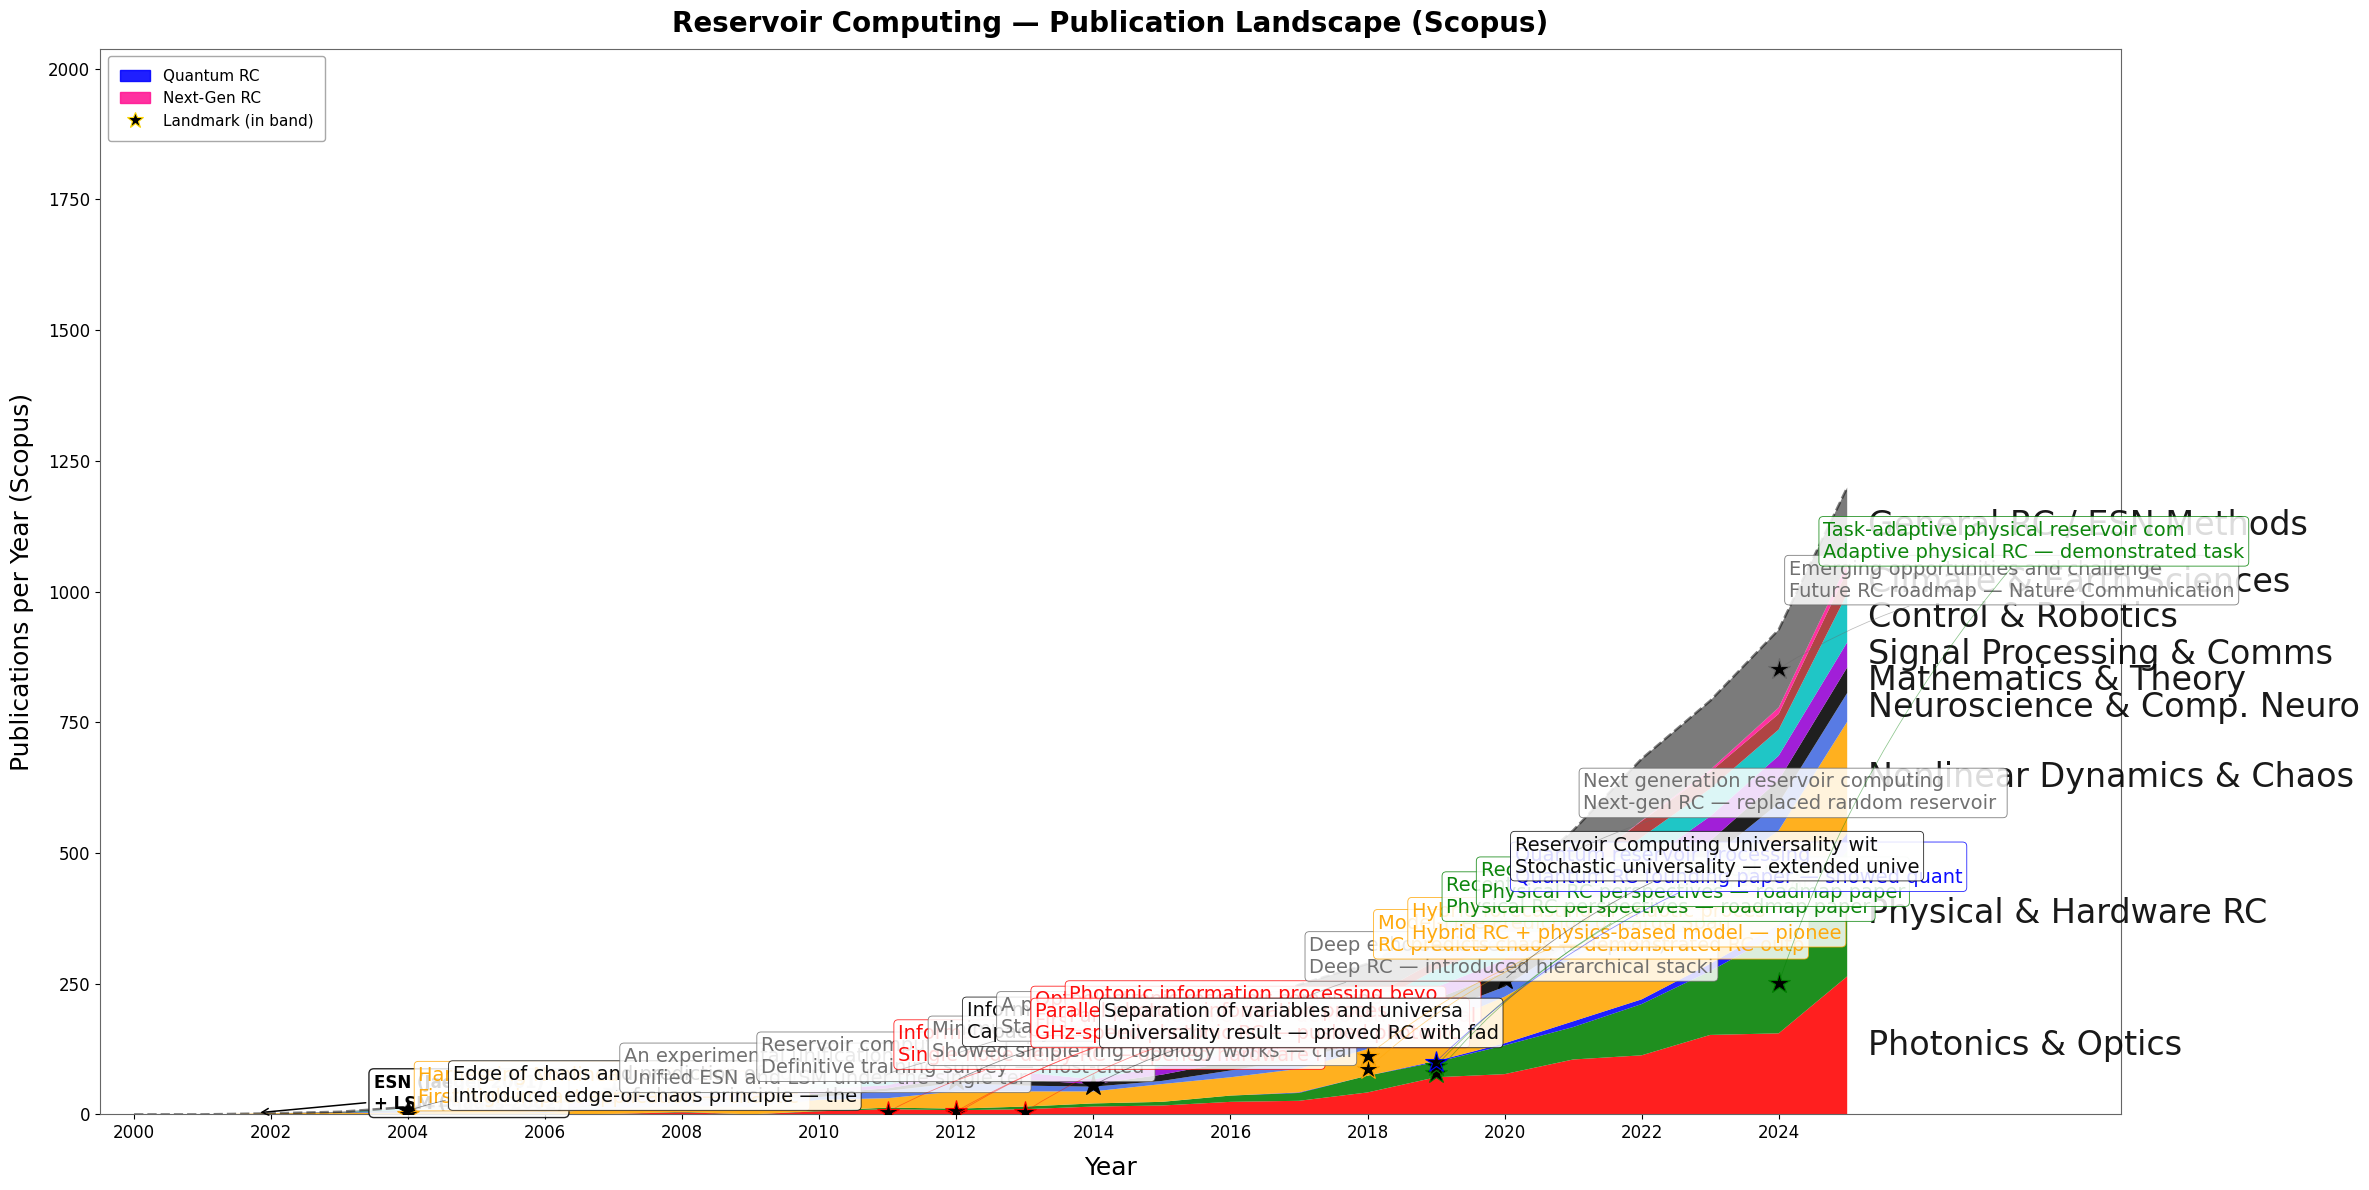


Plotting normalised figure...
Saved -> 'rc_scopus_landscape_normalized.png'


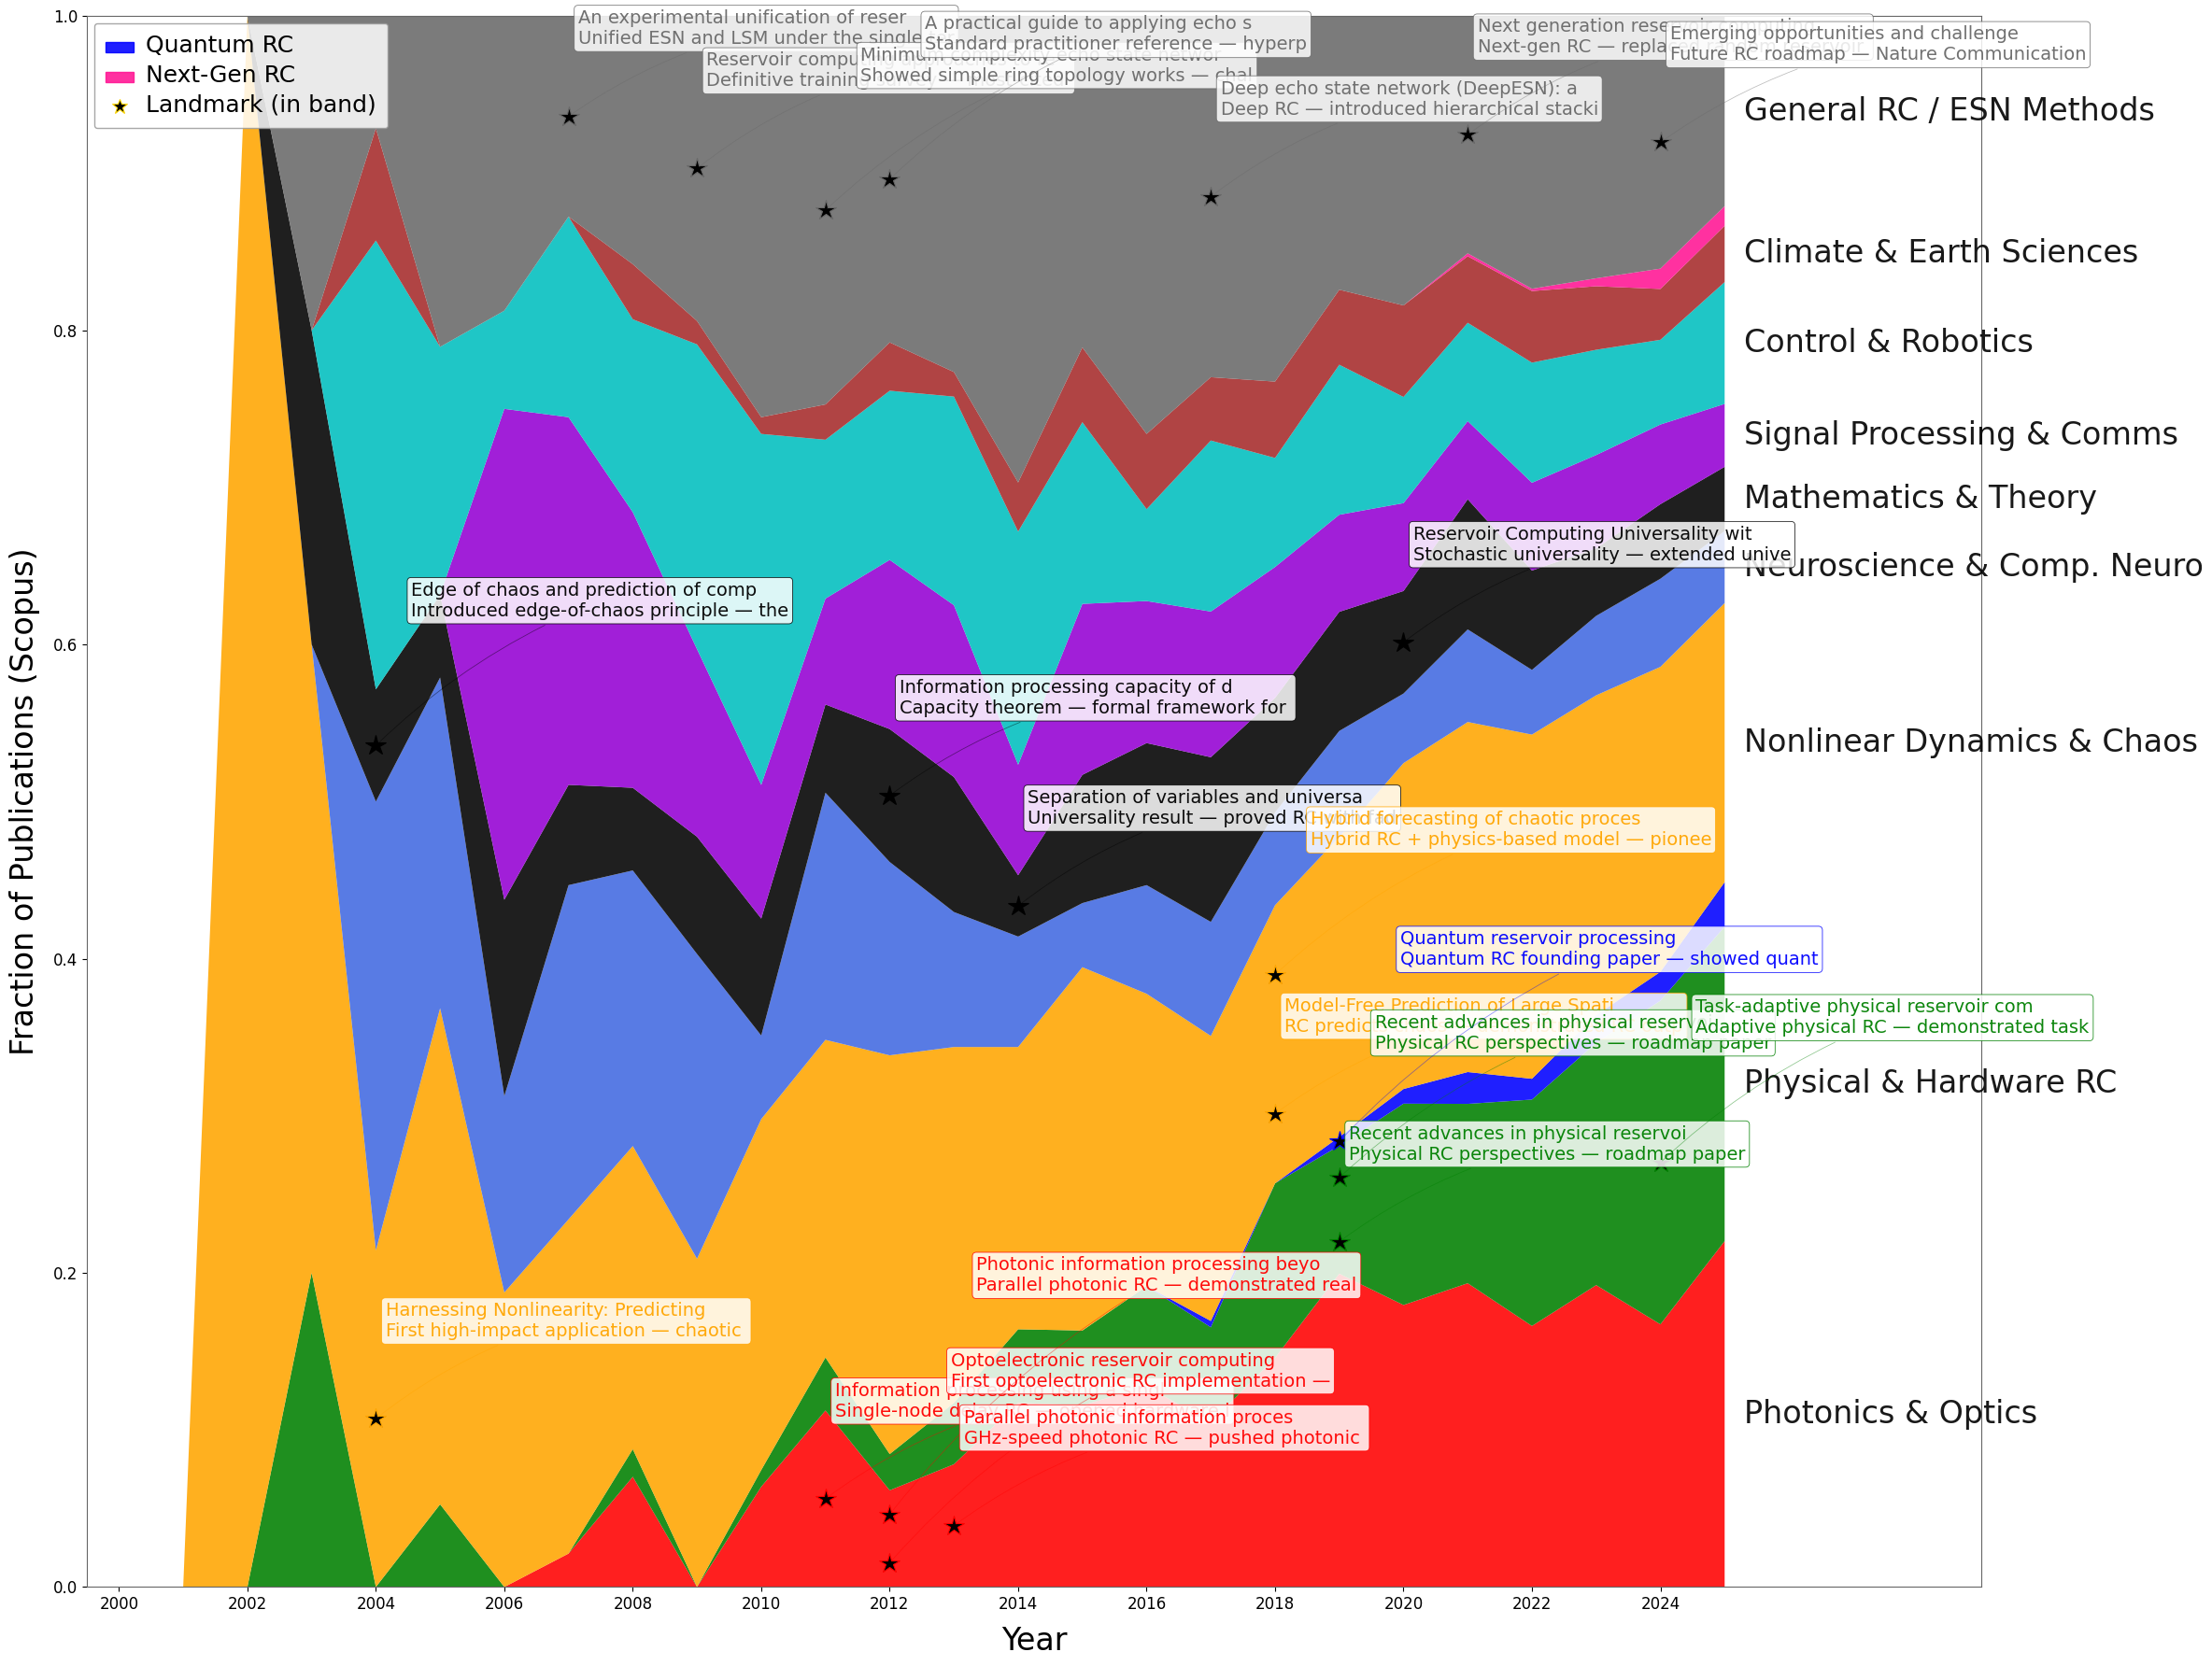


Plotting absolute early-window figure...
Saved -> 'rc_landscape_early_window.png'


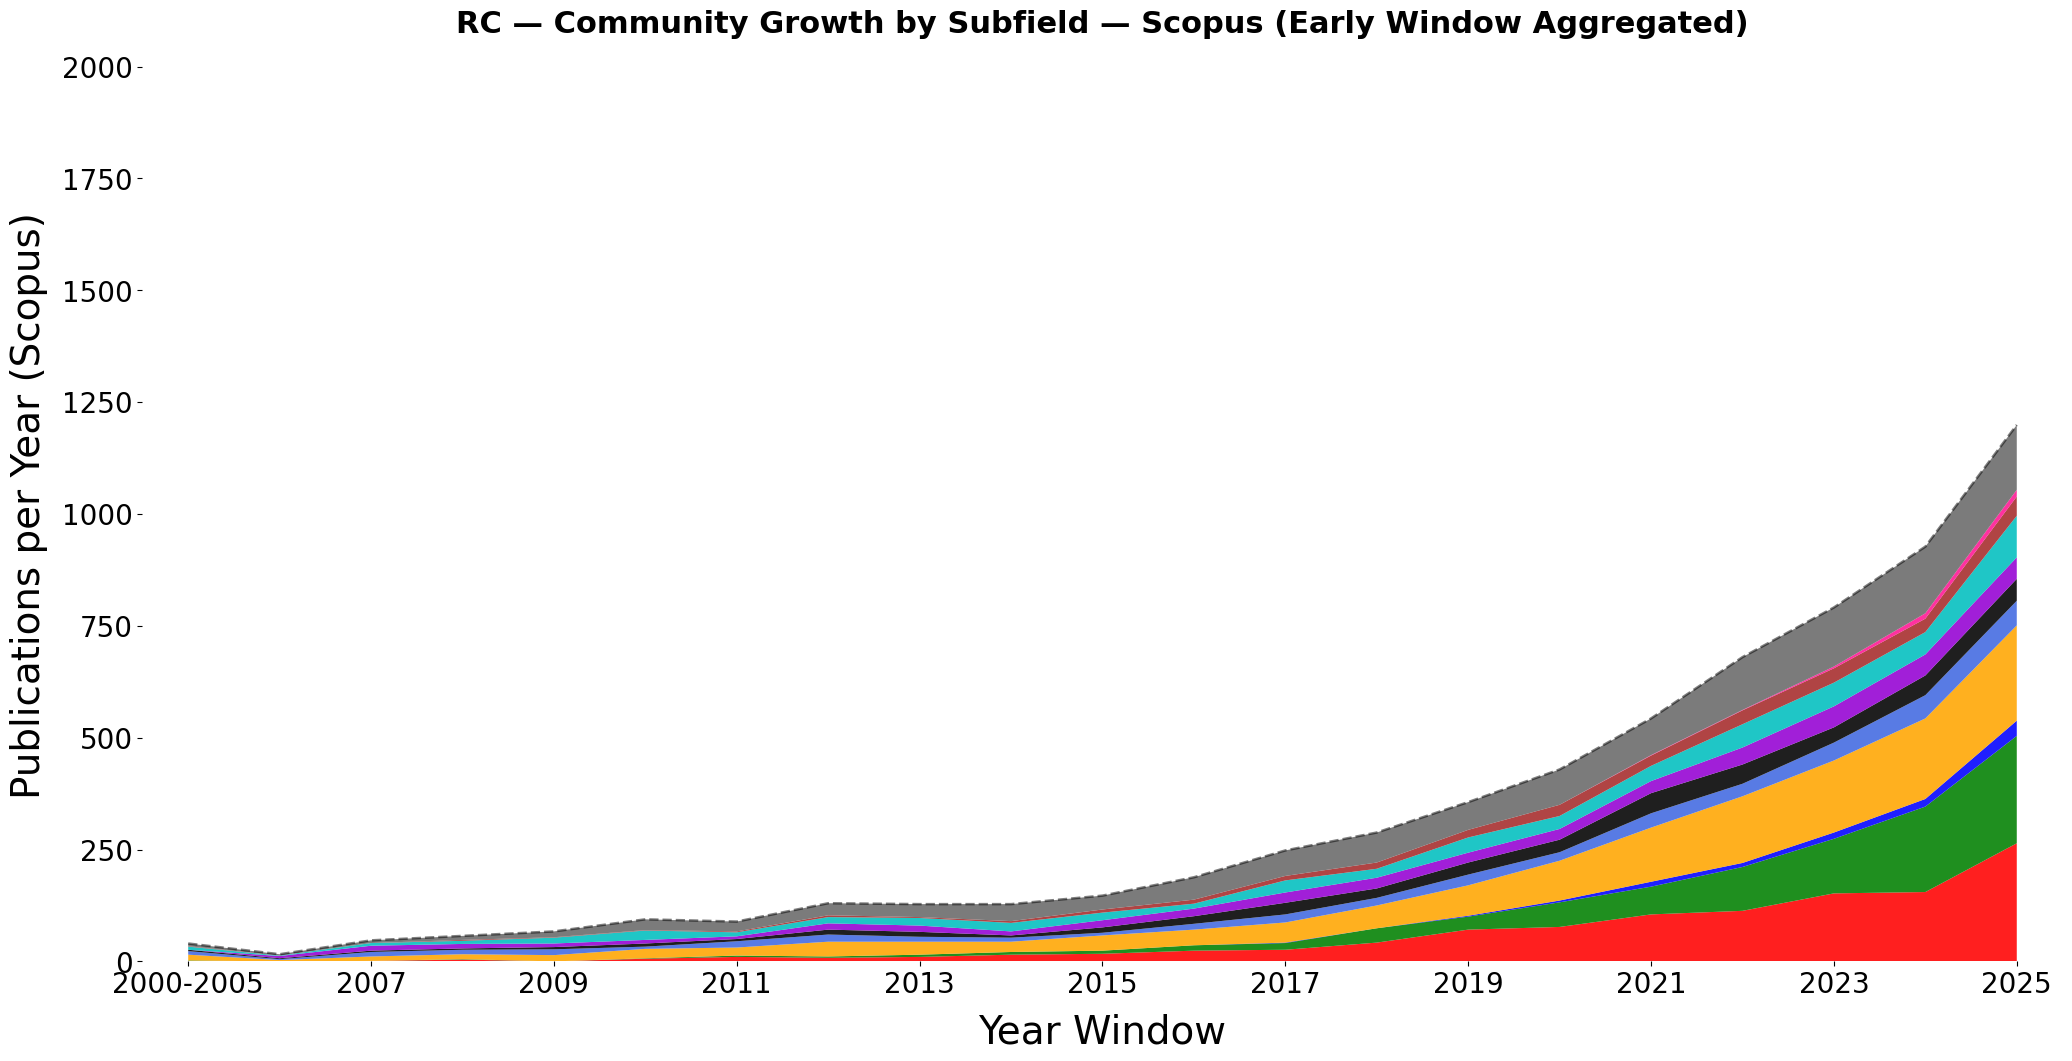


Plotting normalised early-window figure...
Saved -> 'rc_landscape_early_window_normalized.png' (+ .svg)


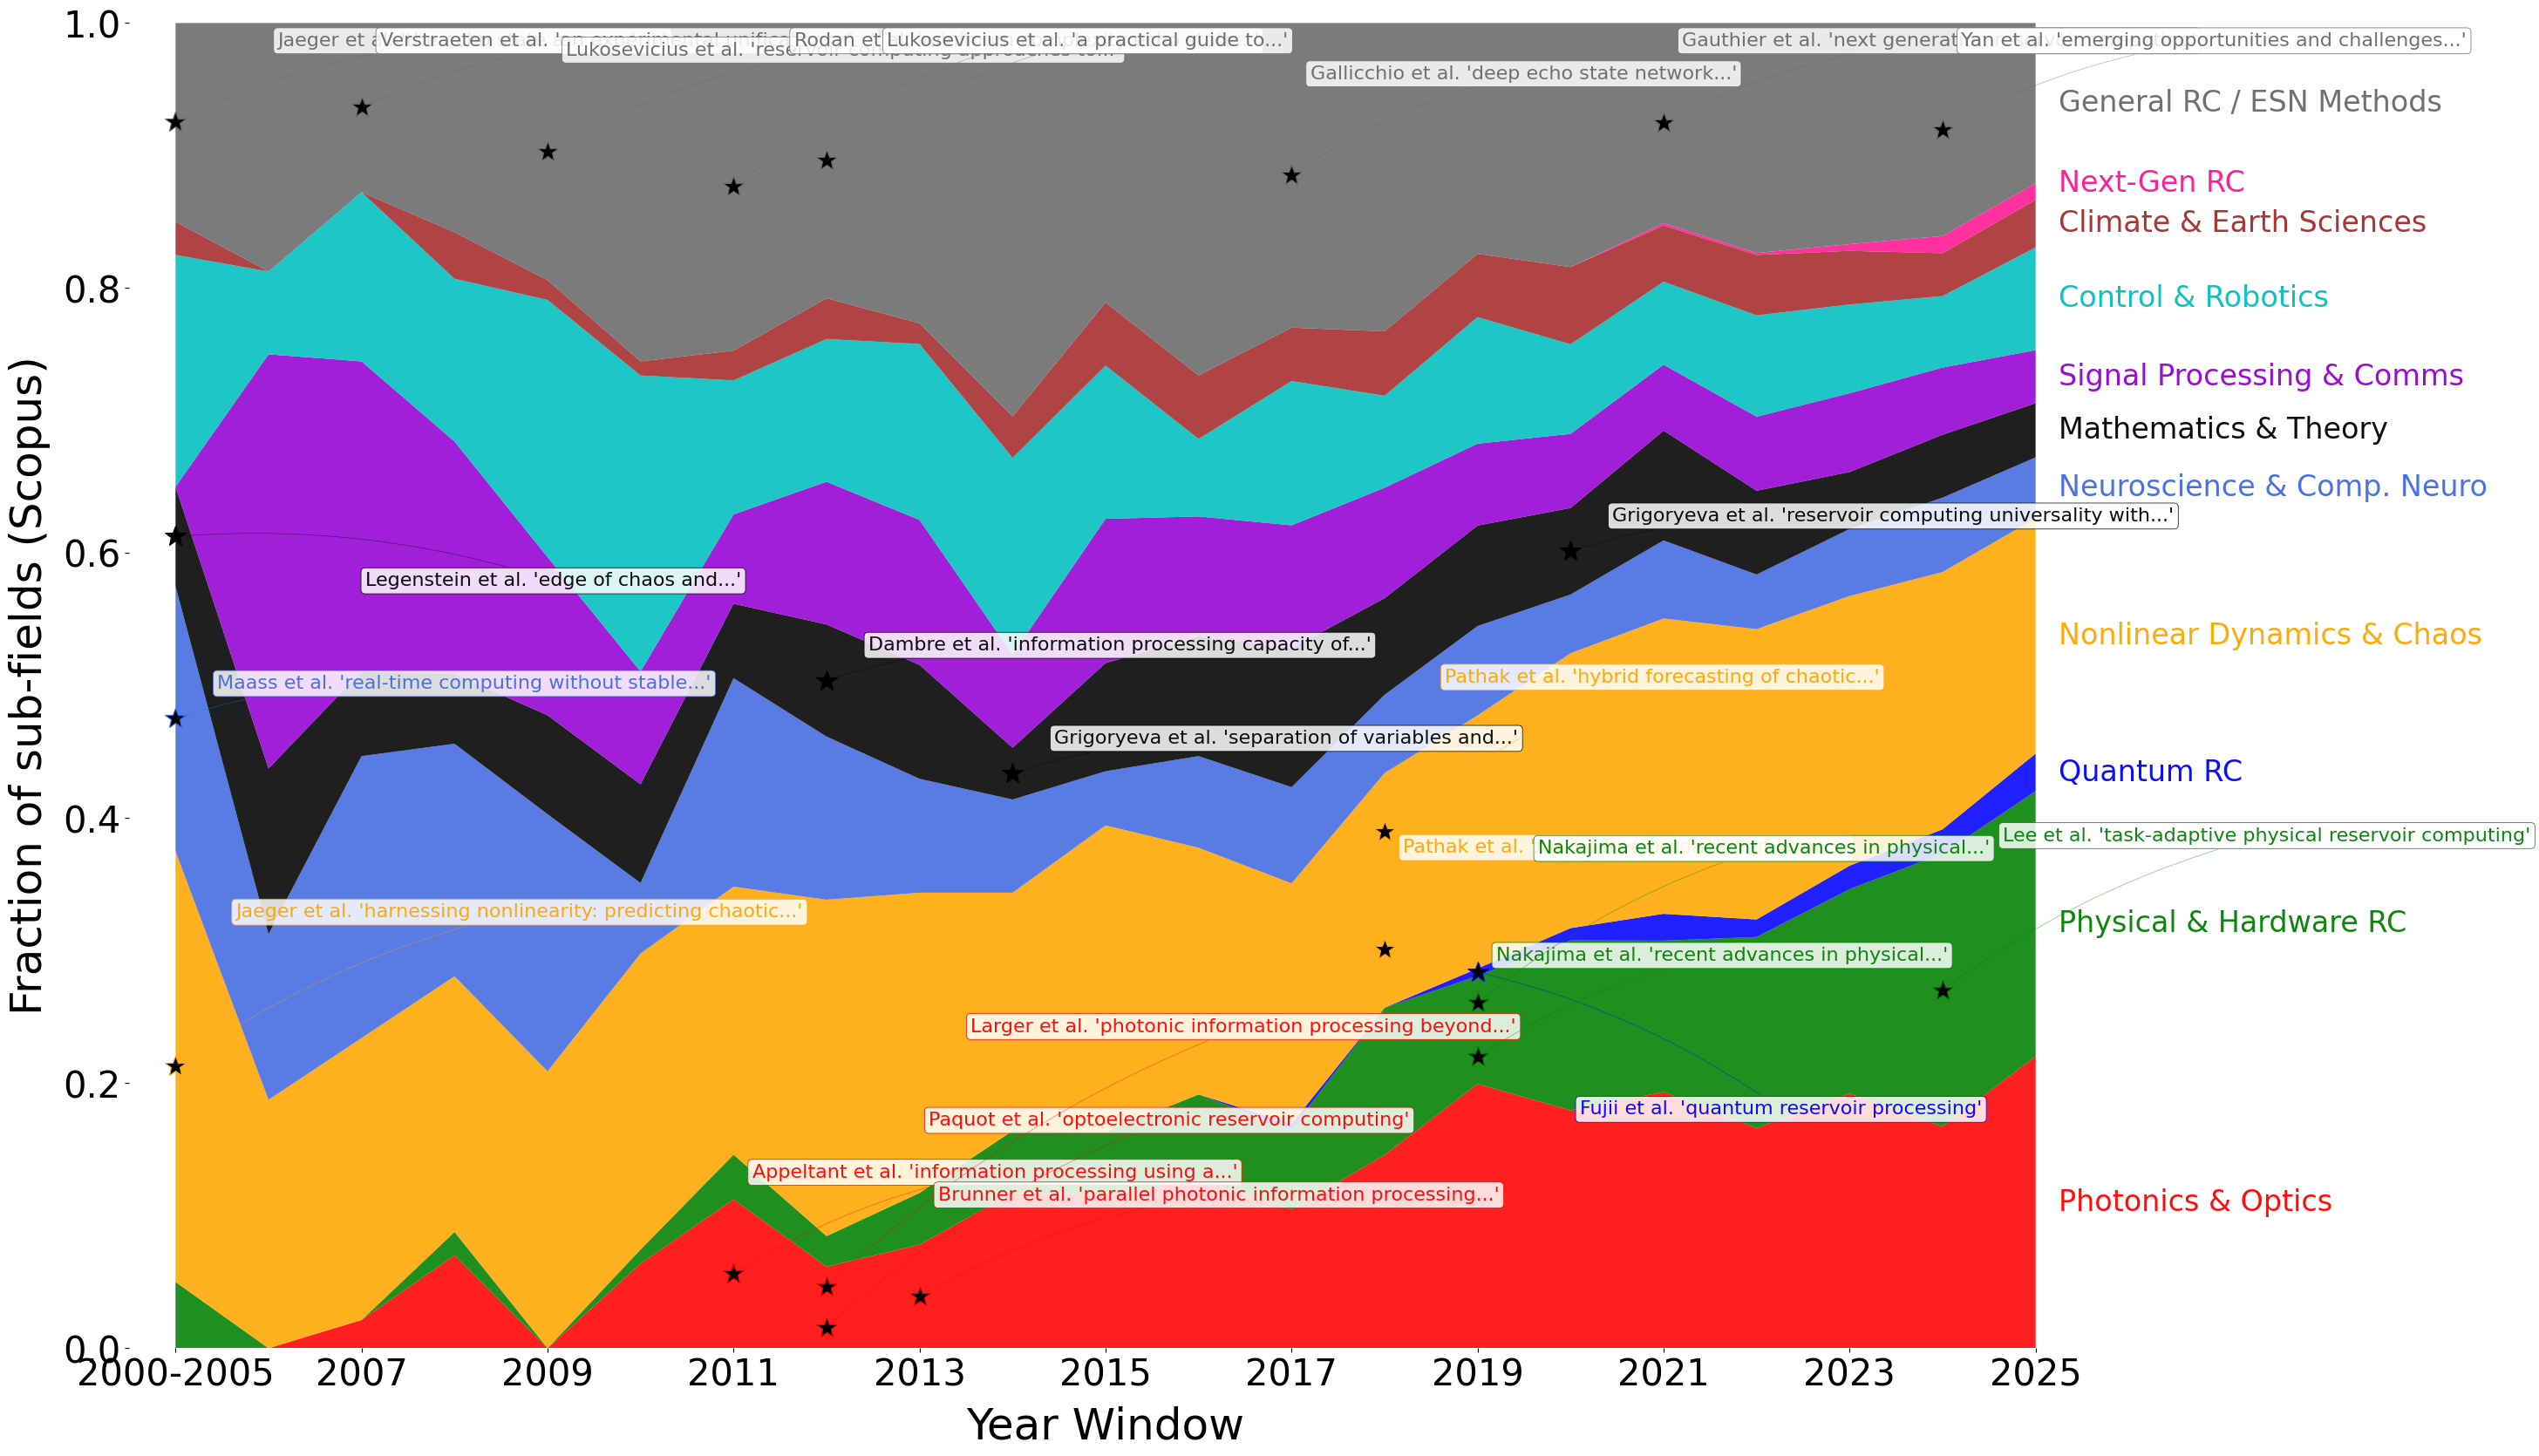


Plotting composite Fig 1...


C:\Users\genxm\AppData\Local\Temp\ipykernel_29560\687091885.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved -> 'rc_scopus_Fig1.png'


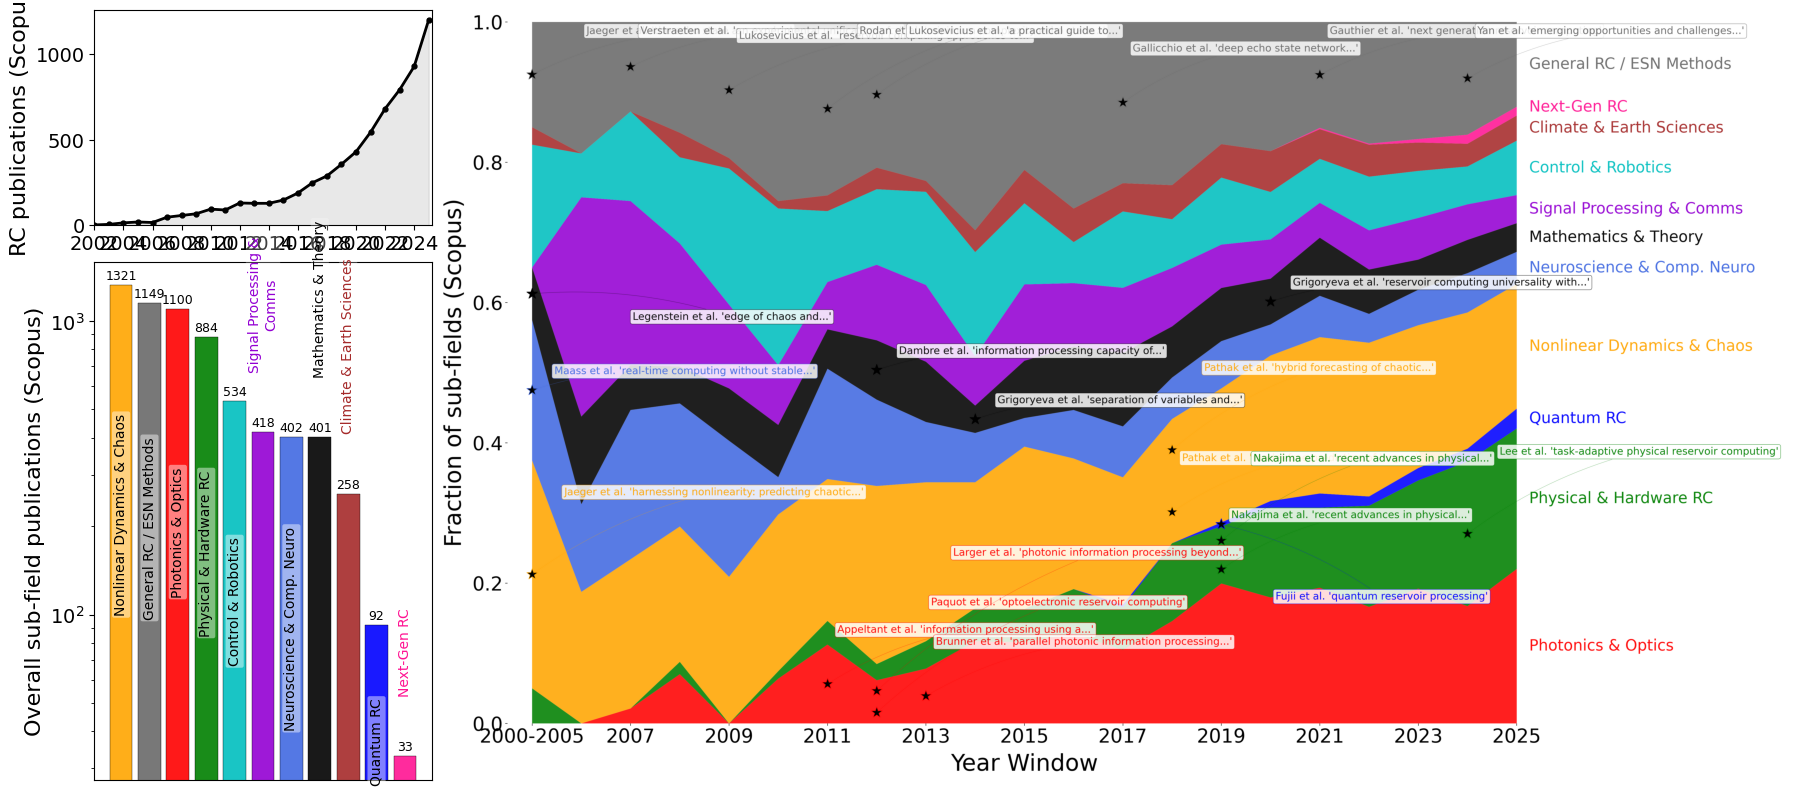


All done.


In [25]:
import scopus_data_analyze as scopus

# ── 1. Load & merge Scopus files ─────────────────────────────────
print("\n── Loading Scopus files ──")
papers = scopus.merge_scopus_files(SCOPUS_CSV_2000_2015, SCOPUS_CSV_2016_2025)

# ── 2. Write merged CSV ──────────────────────────────────────────
with open(OUTPUT_MERGED, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=OUTPUT_FIELDS, extrasaction="ignore")
    writer.writeheader()
    writer.writerows(papers)
print(f"\n✓ Merged {len(papers):,} papers → '{OUTPUT_MERGED}'")

# ── 3. Subfield breakdown ─────────────────────────────────────────
sf_map = defaultdict(int)
for p in papers:
    sf_map[(p.get("subfield") or DEFAULT_SUBFIELD)] += 1
mx = max(sf_map.values()) if sf_map else 1
print("\nSubfield breakdown:")
for label, n in sorted(sf_map.items(), key=lambda x: -x[1]):
    print(f"  {label:<45} {n:>5}  {'█' * (n * 35 // mx)}")

# ── 4. Landmarks ──────────────────────────────────────────────────
print(f"\nLoading landmarks from '{LANDMARK_CSV}'...")
landmarks = load_landmarks(papers, LANDMARK_CSV)
print(f"Total landmarks: {len(landmarks)}\n")

# ── 5. Build matrices ─────────────────────────────────────────────
all_sf = set(p.get("subfield", "") for p in papers)
order  = SUBFIELD_ORDER + sorted(sf for sf in all_sf
                                    if sf not in SUBFIELD_ORDER and sf)

years  = list(range(YEARS[0], YEARS[1] + 1))
matrix = build_matrix(papers, order, years)
totals = matrix.sum(axis=0)

print("Matrix shape:", matrix.shape)
print("Totals:", totals.tolist())

years_early  = list(range(EARLY_WINDOW_END, YEARS[1] + 1))
matrix_early = build_matrix_early_window(papers, order, years_early)
totals_early = matrix_early.sum(axis=0)

# ── 6. Plots ──────────────────────────────────────────────────────
print("\nPlotting absolute figure...")
plot_absolute(papers, landmarks, order, matrix, years, totals)

print("\nPlotting normalised figure...")
plot_normalised(papers, landmarks, order, matrix, years, totals)

print("\nPlotting absolute early-window figure...")
plot_absolute_early_window(papers, landmarks, order, matrix_early, years_early, totals_early)

print("\nPlotting normalised early-window figure...")
plot_normalised_early_window(papers, landmarks, order, matrix_early, years_early, totals_early)

print("\nPlotting composite Fig 1...")
plot_fig1_composite(papers)

print("\nAll done.")

C:\Users\genxm\AppData\Local\Temp\ipykernel_29560\908712160.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved -> 'rc_scopus_Fig1.png'


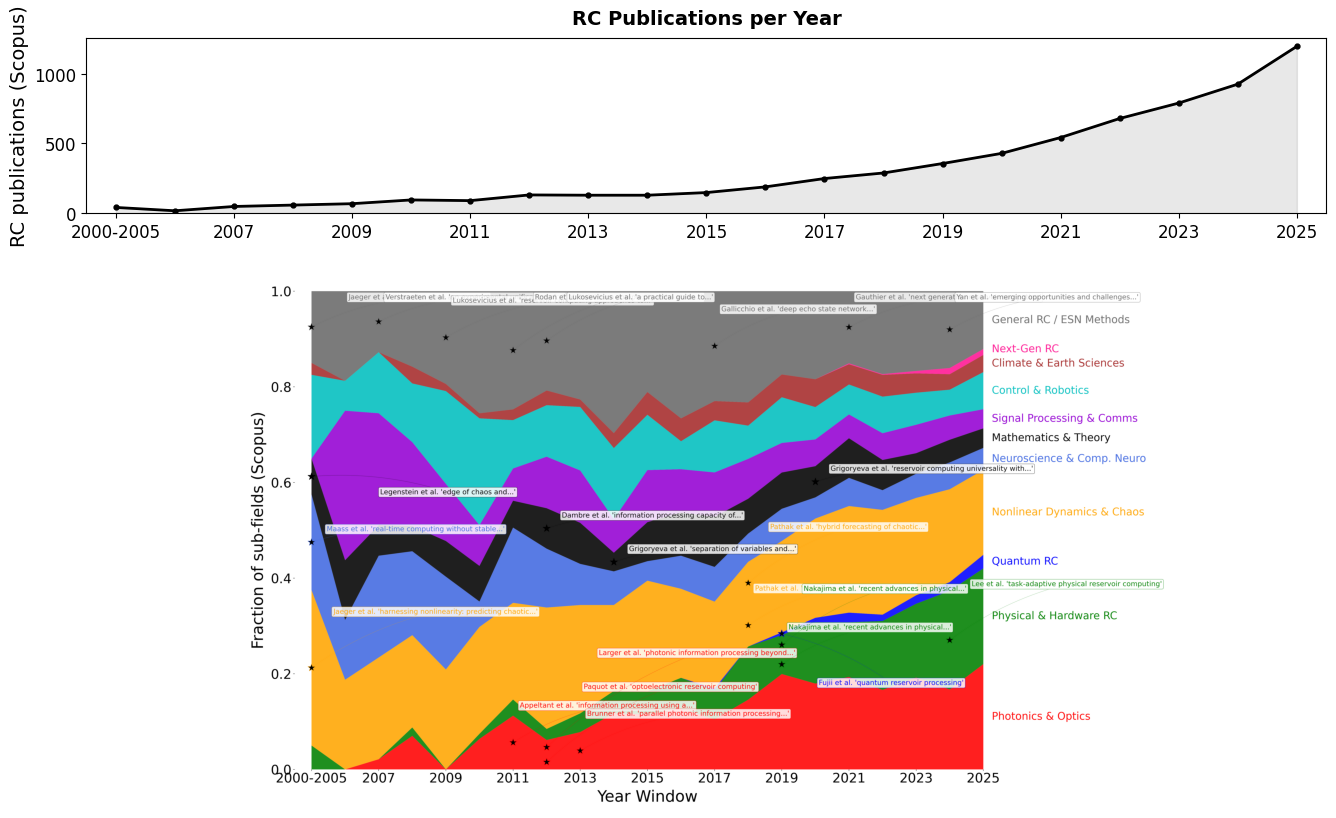

In [26]:
def plot_fig1_composite_2(papers):
    """Two-panel Fig 1: (row 1) papers/year, (row 2) normalised early-window stackplot loaded from saved PNG."""

    # ── Panel 1 data: RC papers per year ─────────────────────────────
    year_counts = defaultdict(int)
    for p in papers:
        try:
            y = int(p.get("year"))
        except (TypeError, ValueError):
            continue
        if YEARS[0] <= y <= 2025:
            year_counts[y] += 1

    # Aggregate 2000-EARLY_WINDOW_END into a single bucket at EARLY_WINDOW_END,
    # matching the x-axis of subfig2 (early-window normalised image)
    years_line  = [EARLY_WINDOW_END] + list(range(EARLY_WINDOW_END + 1, 2026))
    counts_line = [sum(year_counts.get(y, 0) for y in range(YEARS[0], EARLY_WINDOW_END + 1))]
    counts_line += [year_counts.get(y, 0) for y in range(EARLY_WINDOW_END + 1, 2026)]

    # ── Layout ────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(16, 10))
    gs  = GridSpec(2, 1, figure=fig,
                   height_ratios=[1, 3],
                   hspace=0.2)
    ax1 = fig.add_subplot(gs[0])
    ax3 = fig.add_subplot(gs[1])

    # Panel 1: papers per year (early-window x-axis to match subfig2)
    ax1.plot(years_line, counts_line, color="black", linewidth=2.0,
             marker="o", markersize=3.5)
    ax1.fill_between(years_line, counts_line, color="gray", alpha=0.18)
    ax1.set_ylabel("RC publications (Scopus)", fontsize=14)

    ticks1  = [EARLY_WINDOW_END] + [y for y in range(EARLY_WINDOW_END + 2, YEARS[1] + 1, 2)]
    labels1 = [f"{YEARS[0]}-{EARLY_WINDOW_END}"] + [str(y) for y in ticks1[1:]]
    ax1.set_xticks(ticks1)
    ax1.set_xticklabels(labels1, fontsize=12)
    ax1.tick_params(axis="y", labelsize=12)
    ax1.set_xlim(EARLY_WINDOW_END - 0.5, YEARS[1] + 0.5)
    ax1.set_ylim(bottom=0)
    ax1.set_axisbelow(True)
    ax1.set_title("RC Publications per Year", fontsize=14, fontweight="bold", pad=10)

    # Panel 2: saved normalised early-window PNG
    img_path = Path(OUTPUT_NORM_EARLY)
    if img_path.exists():
        img = plt.imread(img_path)
        ax3.imshow(img)
        ax3.axis("off")
    else:
        ax3.text(0.5, 0.5, f"Image not found:\n{OUTPUT_NORM_EARLY}",
                 ha="center", va="center", fontsize=12)
        ax3.set_xticks([]); ax3.set_yticks([])

    plt.tight_layout()
    plt.savefig(OUTPUT_FIG1, dpi=200, bbox_inches="tight")
    print(f"Saved -> '{OUTPUT_FIG1}'")
    plt.show()

plot_fig1_composite_2(papers)

C:\Users\genxm\AppData\Local\Temp\ipykernel_29560\3502548554.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved -> 'rc_scopus_Fig1.png'


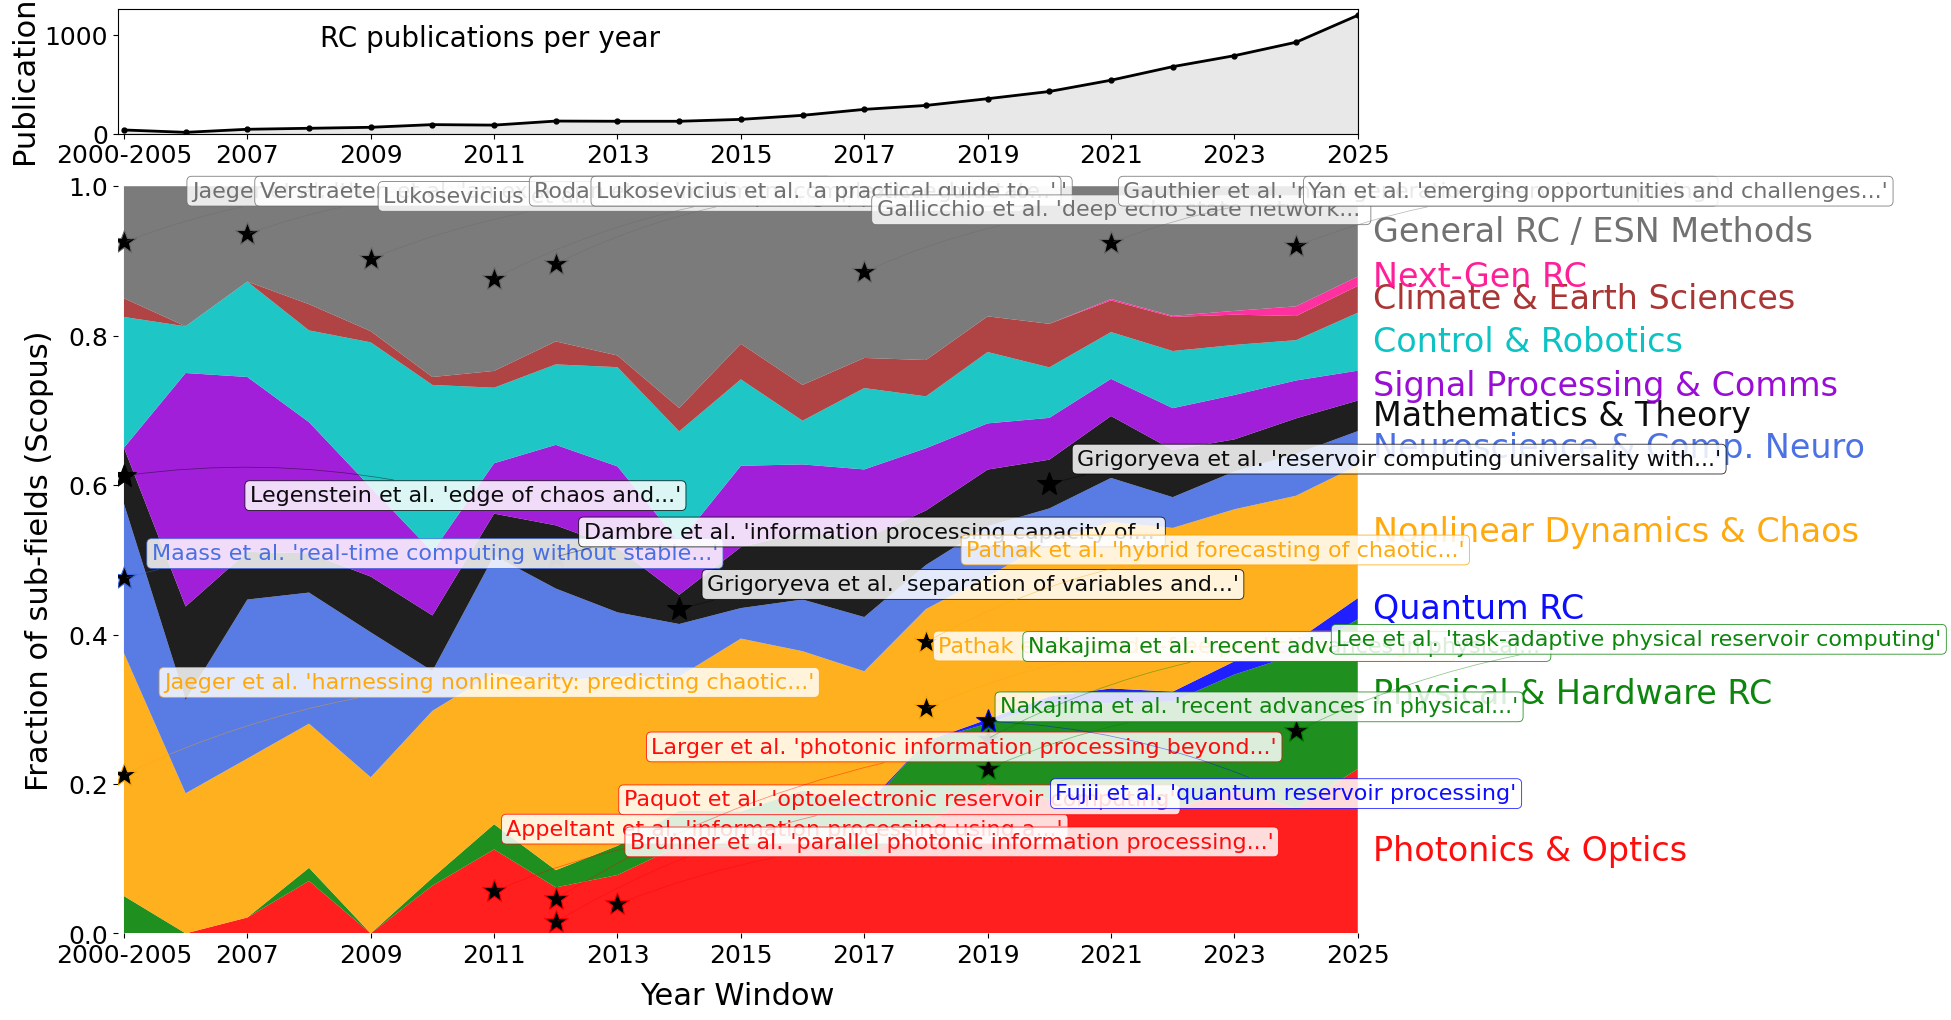

In [46]:
def plot_fig1_composite_2(papers, landmarks=None):
    """Two-panel Fig 1 with aligned x-axes:
    (top) RC papers/year, (bottom) normalised early-window stackplot drawn directly."""
    if landmarks is None:
        landmarks = []

    # ── Panel 1 data: RC papers per year ─────────────────────────────
    year_counts = defaultdict(int)
    for p in papers:
        try:
            y = int(p.get("year"))
        except (TypeError, ValueError):
            continue
        if YEARS[0] <= y <= 2025:
            year_counts[y] += 1

    # Aggregate 2000-EARLY_WINDOW_END into a single bucket at EARLY_WINDOW_END
    years_line  = [EARLY_WINDOW_END] + list(range(EARLY_WINDOW_END + 1, 2026))
    counts_line = [sum(year_counts.get(y, 0) for y in range(YEARS[0], EARLY_WINDOW_END + 1))]
    counts_line += [year_counts.get(y, 0) for y in range(EARLY_WINDOW_END + 1, 2026)]

    # ── Panel 2 data: early-window normalised stackplot ───────────────
    all_sf      = set(p.get("subfield", "") for p in papers)
    order       = SUBFIELD_ORDER + sorted(sf for sf in all_sf if sf not in SUBFIELD_ORDER and sf)
    years_early = list(range(EARLY_WINDOW_END, YEARS[1] + 1))
    matrix_ew   = build_matrix_early_window(papers, order, years_early)
    totals_ew   = matrix_ew.sum(axis=0)
    norm_matrix = matrix_ew / np.where(totals_ew > 0, totals_ew, 1.0)
    colors      = [SUBFIELD_COLORS.get(sf, "#aaaaaa") for sf in order]

    # Shared x-axis parameters (both panels use identical limits)
    x_min  = EARLY_WINDOW_END - 0.1
    x_max  = YEARS[1] + 0
    ticks  = [EARLY_WINDOW_END] + [y for y in range(EARLY_WINDOW_END + 2, YEARS[1] + 1, 2)]
    tlbls  = [f"{YEARS[0]}-{EARLY_WINDOW_END}"] + [str(y) for y in ticks[1:]]

    # ── Layout ────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(16, 12))
    gs  = GridSpec(2, 1, figure=fig, height_ratios=[0.5, 3], hspace=0.12)
    ax1 = fig.add_subplot(gs[0])
    ax3 = fig.add_subplot(gs[1])

    # ── Panel 1: RC papers per year ───────────────────────────────────
    ax1.plot(years_line, counts_line, color="black", linewidth=2.0,
             marker="o", markersize=3.5)
    ax1.fill_between(years_line, counts_line, color="gray", alpha=0.18)
    ###shifting the y-label to the downwards by 10 points
    ax1.set_ylabel("Publications", fontsize=22)
    ###putting a text inside the plot
    ax1.text(0.3, 0.7, "RC publications per year", transform=ax1.transAxes, fontsize=20, ha='center')
    ax1.set_xticks(ticks)
    ax1.set_xticklabels(tlbls, fontsize=18)
    ax1.tick_params(axis="y", labelsize=18)
    ax1.set_xlim(x_min, x_max)
    ax1.set_ylim(bottom=0)
    ax1.set_axisbelow(True)

    # ── Panel 2: normalised early-window stackplot ────────────────────
    ax3.stackplot(years_early, norm_matrix, colors=colors, alpha=0.88, linewidth=0)
    draw_band_labels_early(ax3, order, matrix_ew, totals_ew, years_early, normalised=True)
    # Allow band labels to render beyond axes edge (same as standalone plot)
    for txt in ax3.texts:
        txt.set_clip_on(False)
    if landmarks:
        place_landmarks_early_window(ax3, landmarks, order, matrix_ew,
                                     years_early, totals_ew, normalised=True)
    ax3.set_yticks(np.linspace(0.0, 1.0, 6))
    ax3.set_yticklabels([f"{v:.1f}" for v in np.linspace(0.0, 1.0, 6)])
    ax3.set_xlim(x_min, x_max)
    ax3.set_ylim(0, 1.0)
    ax3.set_xlabel("Year Window", color="black", fontsize=22, labelpad=10)
    ax3.set_ylabel("Fraction of sub-fields (Scopus)", color="black", fontsize=22, labelpad=10)
    _style_early_window(ax3, years_early)
    ax3.tick_params(axis="both", which="major", labelsize=18)

    plt.tight_layout()
    plt.savefig(OUTPUT_FIG1, dpi=200, bbox_inches="tight")
    print(f"Saved -> '{OUTPUT_FIG1}'")
    plt.show()

plot_fig1_composite_2(papers, landmarks)